# 02. Host-Pest Interaction analysis and Species Distribution Modeling

This notebook builds upon (01_eda.ipynb) to execute three core analytical phases:

1. **Host-Pest Interaction Analysis**
    Examines the **1,673 records** with confirmed host plant data.
    Identifies fly-plant associations and quantifies host and pest diversity.

2. **Environmental Covariate Extraction**
   Samples WorldClim bioclimatic variables, elevation, soil clay content, and soil pH at all reliable occurrence locations.
   Generates an environmental baseline matrix linking each observation to its local conditions.

3. **Species Distribution Modeling (SDM)**
   Trains predictive models for key species based on environmental preferences.
   Maps ecological suitability across the target study region.

### Data Inputs
* (data/clean_data.csv)Cleaned occurrence dataset (from notebook 01).
* (Environmental_Layers) Environmental raster layers (WorldClim bio_1 to bio_19, elevation, soil clay, and soil pH).

# Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import os

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

# Load cleaned data

In [8]:
df = pd.read_csv('../data/clean_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (9199, 30)


,id,uuid,observed_on,obs_year,obs_month,quality_grade,license,latitude,longitude,positional_accuracy,coordinates_obscured,place_country_name,place_state_name,place_admin1_name,species_guess,scientific_name,common_name,taxon_genus_name,taxon_species_name,host_plant,Data_Category,num_identification_agreements,num_identification_disagreements,url,image_url,taxon_resolution,has_host_plant,is_research_grade,has_coords,coord_reliable
0,229489,6bb20884-a1a8-4a32-a5c8-2cbed47d5ad6,2013-04-05,2013,4,needs_id,CC-BY-NC,24.432020,92.330689,31626.0,False,India,Assam,Assam,Bactrocera,Bactrocera,NaN,Bactrocera,NaN,Unknown,Occurrence Only,2,0,http://www.inaturalist.org/observations/229489,https://inaturalist-open-data.s3.amazonaws.com...,genus_or_higher,False,False,True,False
1,663857,3fca9700-5ad3-4232-93d3-04e460a1f13b,2011-10-14,2011,10,research,NaN,38.195269,13.335471,16.0,False,Italy,Sicily,Sicily,olive fruit fly,Bactrocera oleae,olive fruit fly,Bactrocera,Bactrocera oleae,Olea europaea,Interaction Study,2,0,http://www.inaturalist.org/observations/663857,https://static.inaturalist.org/photos/836423/m...,species,True,True,True,True
2,718148,997499b2-e0c4-4ce4-a15c-ff813133a315,2014-06-04,2014,6,research,CC-BY-NC-SA,1.348855,103.762573,NaN,False,Singapore,West,West,Bactrocera dorsalis,Bactrocera dorsalis,Oriental Fruit Fly,Bactrocera,Bactrocera dorsalis,Unknown,Occurrence Only,2,0,http://www.inaturalist.org/observations/718148,https://inaturalist-open-data.s3.amazonaws.com...,species,False,True,True,True
3,783490,446949ef-1baa-4e13-98f9-f0b44039a3ee,2014-07-06,2014,7,research,CC-BY-NC-ND,22.430309,114.086419,61.0,False,Hong Kong,Yuen Long,Yuen Long,æ±æ–¹æžœå¯¦è …,Bactrocera dorsalis,Oriental Fruit Fly,Bactrocera,Bactrocera dorsalis,Unknown,Occurrence Only,1,0,http://www.inaturalist.org/observations/783490,https://inaturalist-open-data.s3.amazonaws.com...,species,False,True,True,True
4,791094,068abc8d-e1f1-447b-929d-35c63506c014,2014-07-12,2014,7,research,CC-BY-NC-ND,1.317138,103.815919,217.0,False,Singapore,Central,Central,Bactrocera dorsalis,Bactrocera dorsalis,Oriental Fruit Fly,Bactrocera,Bactrocera dorsalis,Unknown,Occurrence Only,2,0,http://www.inaturalist.org/observations/791094,https://inaturalist-open-data.s3.amazonaws.com...,species,False,True,True,True


## Part 1: Host-Pest interaction Analysis

Using only the records with a known host plant (`Data_Category == 'Interaction Study'`), look at which fly species associate with which host plants.

In [9]:
interactions = df[df['Data_Category'] == 'Interaction Study'].copy()
print('Interaction-study records:', len(interactions))
print('Unique species:', interactions['scientific_name'].nunique())
print('Unique host plants:', interactions['host_plant'].nunique())

Interaction-study records: 1673
Unique species: 32
Unique host plants: 12


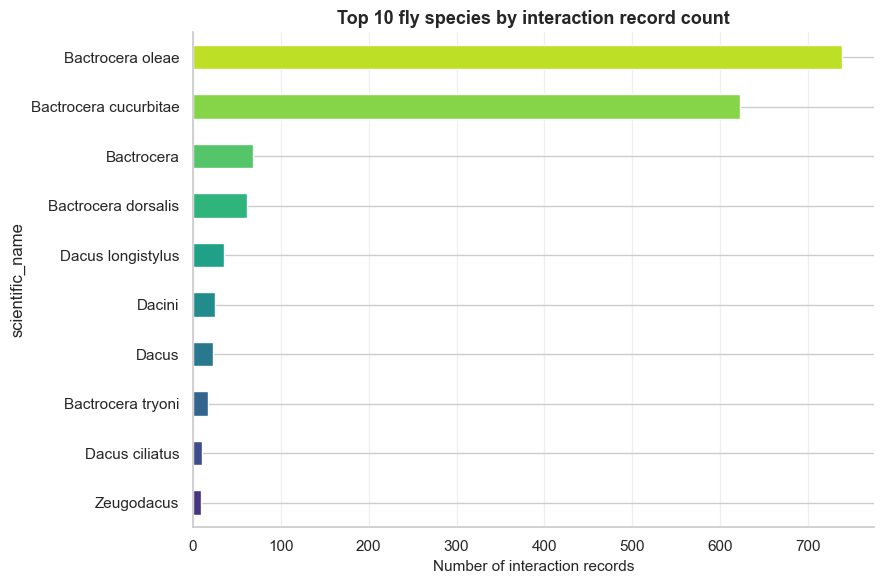

In [10]:
top_species = interactions['scientific_name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(top_species)))
top_species.sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of interaction records', fontsize=11)
ax.set_title('Top 10 fly species by interaction record count', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/top_species_interactions.png', dpi=150)
plt.show()

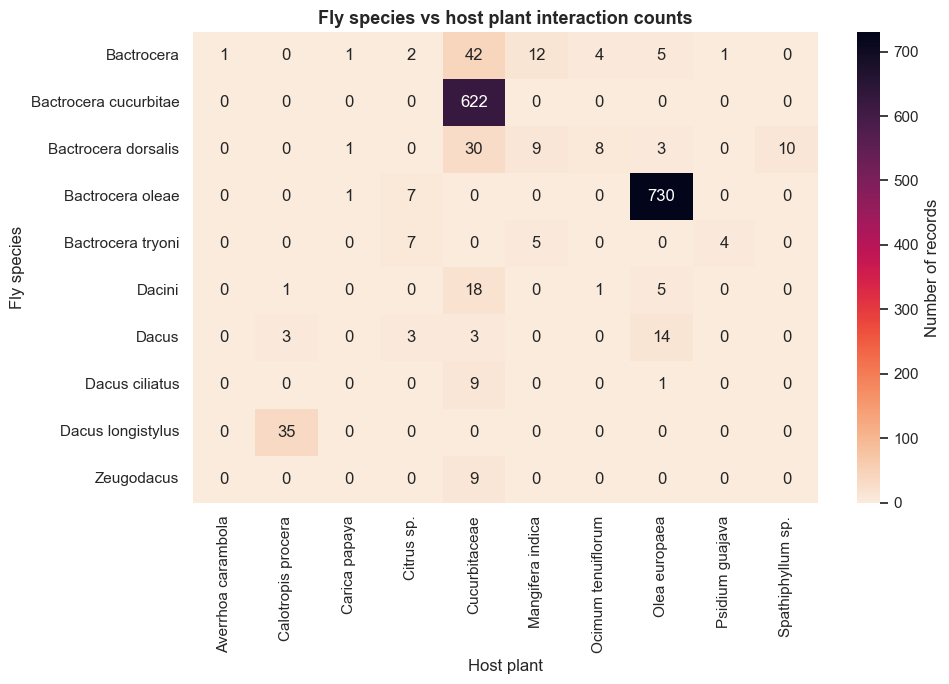

In [13]:
top_hosts = interactions['host_plant'].value_counts().head(10).index
top_sp = top_species.index

matrix = pd.crosstab(
    interactions[interactions['scientific_name'].isin(top_sp)]['scientific_name'],
    interactions[interactions['host_plant'].isin(top_hosts)]['host_plant']
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(matrix, annot=True, fmt='d', cmap='rocket_r', ax=ax, cbar_kws={'label': 'Number of records'})
ax.set_title('Fly species vs host plant interaction counts', fontsize=13, fontweight='bold')
ax.set_xlabel('Host plant')
ax.set_ylabel('Fly species')
plt.tight_layout()
plt.savefig('../outputs/figures/species_host_heatmap.png', dpi=150)
plt.show()

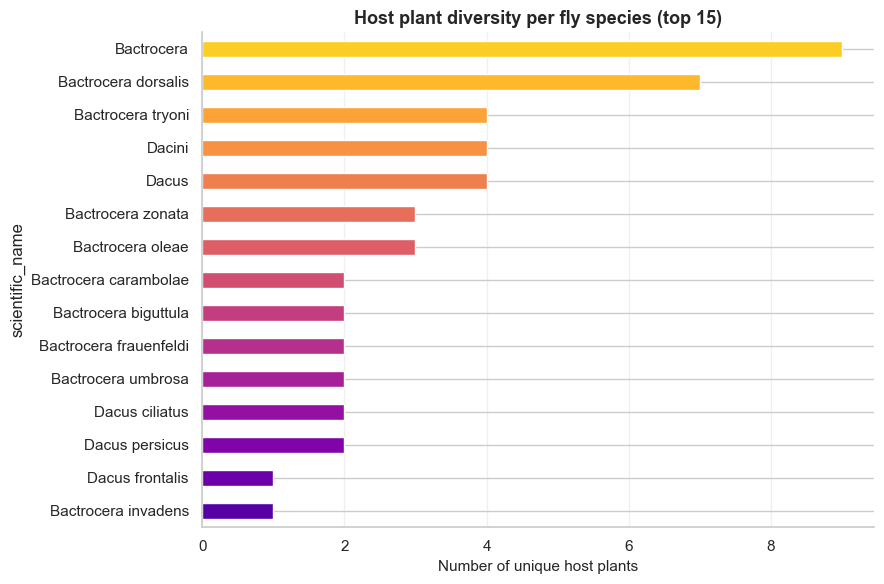

In [15]:
host_diversity = interactions.groupby('scientific_name')['host_plant'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
n = min(15, len(host_diversity))
colors = plt.cm.plasma(np.linspace(0.15, 0.9, n))
host_diversity.head(n).sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of unique host plants', fontsize=11)
ax.set_title('Host plant diversity per fly species (top 15)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/host_diversity_per_species.png', dpi=150)
plt.show()

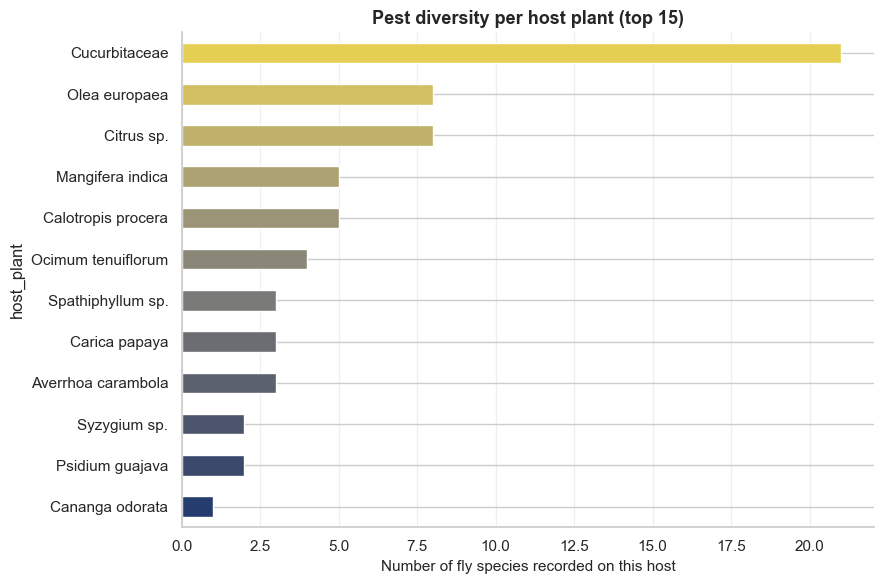

In [16]:
pest_diversity = interactions.groupby('host_plant')['scientific_name'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
n = min(15, len(pest_diversity))
colors = plt.cm.cividis(np.linspace(0.15, 0.9, n))
pest_diversity.head(n).sort_values().plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Number of fly species recorded on this host', fontsize=11)
ax.set_title('Pest diversity per host plant (top 15)', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/pest_diversity_per_host.png', dpi=150)
plt.show()

## Part 2: Extract Environmental Covariates

For every occurrence with a reliable coordinate, sample the value of each environmental layer (19 WorldClim bioclimatic variables, elevation, soil clay content, soil pH) at that exact location.

In [17]:
ENV_DIR = 'C:/Users/skimanzi/Desktop/Dacini_SMD_project/Environmental_Layers'

env_files = {
    'bio_1': 'wc2.1_10m_bio_1.tif', 'bio_2': 'wc2.1_10m_bio_2.tif',
    'bio_3': 'wc2.1_10m_bio_3.tif', 'bio_4': 'wc2.1_10m_bio_4.tif',
    'bio_5': 'wc2.1_10m_bio_5.tif', 'bio_6': 'wc2.1_10m_bio_6.tif',
    'bio_7': 'wc2.1_10m_bio_7.tif', 'bio_8': 'wc2.1_10m_bio_8.tif',
    'bio_9': 'wc2.1_10m_bio_9.tif', 'bio_10': 'wc2.1_10m_bio_10.tif',
    'bio_11': 'wc2.1_10m_bio_11.tif', 'bio_12': 'wc2.1_10m_bio_12.tif',
    'bio_13': 'wc2.1_10m_bio_13.tif', 'bio_14': 'wc2.1_10m_bio_14.tif',
    'bio_15': 'wc2.1_10m_bio_15.tif', 'bio_16': 'wc2.1_10m_bio_16.tif',
    'bio_17': 'wc2.1_10m_bio_17.tif', 'bio_18': 'wc2.1_10m_bio_18.tif',
    'bio_19': 'wc2.1_10m_bio_19.tif',
    'elevation': 'wc2.1_10m_elev.tif',
    'clay': 'clay_0-5cm_mean_30s.tif',
    'ph': 'phh2o_0-5cm_mean_30s.tif',
}
env_files = {k: os.path.join(ENV_DIR, v) for k, v in env_files.items()}

missing = [p for p in env_files.values() if not os.path.exists(p)]
print(f'{len(env_files)} layers registered, {len(missing)} missing')
if missing:
    print('Missing files:', missing)

22 layers registered, 0 missing


In [18]:
def extract_covariates(points_df, lat_col='latitude', lon_col='longitude'):
    """Sample every environmental layer at each (lat, lon) point."""
    coords = list(zip(points_df[lon_col], points_df[lat_col]))  # rasterio wants (x, y) = (lon, lat)
    result = points_df.copy()
    for name, path in env_files.items():
        with rasterio.open(path) as src:
            result[name] = [v[0] for v in src.sample(coords)]
    return result

In [19]:
geo_points = df[df['coord_reliable']].copy()
print('Points to extract covariates for:', len(geo_points))

covariates = extract_covariates(geo_points)
covariate_cols = list(env_files.keys())
covariates[['scientific_name', 'latitude', 'longitude'] + covariate_cols].head()

Points to extract covariates for: 8339


,scientific_name,latitude,longitude,bio_1,bio_2,bio_3,bio_4,bio_5,bio_6,bio_7,bio_8,bio_9,bio_10,bio_11,bio_12,bio_13,bio_14,bio_15,bio_16,bio_17,bio_18,bio_19,elevation,clay,ph
1,Bactrocera oleae,38.195269,13.335471,17.525000,6.300000,30.594902,538.091675,28.991667,8.400000,20.591667,15.859722,24.152779,24.525000,11.605556,479.0,70.0,3.0,58.101982,204.0,25.0,61.0,148.0,226,6.0,NaN
2,Bactrocera dorsalis,1.348855,103.762573,26.654299,6.862859,85.067688,43.173588,30.818390,22.750862,8.067528,26.330843,26.946838,27.133286,26.057423,2304.0,297.0,148.0,22.294577,745.0,455.0,533.0,744.0,26,22.0,5.2
3,Bactrocera dorsalis,22.430309,114.086419,22.117931,6.060862,30.716740,510.826660,30.934551,11.203090,19.731461,27.675749,16.988718,27.675749,15.367650,2033.0,365.0,25.0,77.972969,1027.0,90.0,1027.0,101.0,142,8.0,NaN
4,Bactrocera dorsalis,1.317138,103.815919,26.912443,7.008784,85.571693,42.593422,31.095270,22.904730,8.190540,26.317455,27.216892,27.374662,26.317455,2359.0,289.0,157.0,19.926325,760.0,492.0,541.0,760.0,16,23.0,NaN
5,Zeugodacus tau,23.499548,87.304627,26.340918,11.375667,42.699047,454.012024,38.320000,11.678500,26.641499,28.627834,20.248125,31.222500,20.056458,1228.0,273.0,4.0,104.792183,768.0,27.0,300.0,34.0,84,4.0,6.1


In [20]:
# Sanity check: SoilGrids pH is sometimes stored as pH x 10
print('pH range:', covariates['ph'].min(), 'to', covariates['ph'].max())
if covariates['ph'].max() > 14:
    covariates['ph'] = covariates['ph'] / 10
    print('Rescaled pH, new range:', covariates['ph'].min(), 'to', covariates['ph'].max())

pH range: 4.599999904632568 to 9.300000190734863


In [21]:
# Drop rows where any covariate could not be sampled (point fell outside a raster's extent)
before = len(covariates)
covariates = covariates.dropna(subset=covariate_cols)
print(f'Dropped {before - len(covariates)} points with missing covariate values')
print('Remaining points:', len(covariates))
covariates.to_csv('../data/occurrence_covariates.csv', index=False)

Dropped 2030 points with missing covariate values
Remaining points: 6309


## Part 3: Species Distribution Modeling (SDM)

For each of the top fly species (by number of reliable-coordinate occurrences), train a model that distinguishes the environmental conditions at presence points from randomly sampled background points, then use it to map suitability.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_score

# Only model true species-level identifications, not genus/tribe-level records
species_covariates = covariates[covariates['taxon_resolution'] == 'species']
TARGET_SPECIES = species_covariates['scientific_name'].value_counts().head(5).index.tolist()
print('Modeling these species:', TARGET_SPECIES)

Modeling these species: ['Bactrocera dorsalis', 'Bactrocera oleae', 'Zeugodacus tau', 'Bactrocera cucurbitae', 'Bactrocera tryoni']


In [34]:
# Generating background points

def generate_buffered_background(presence_df, n, buffer_deg=5.0, seed=42):
    """
    Generate background points by jittering around actual presence locations,
    rather than sampling a single global bounding box. This avoids the longitude
    wraparound problem (occurrences spanning the antimeridian break a naive
    min/max bounding box) and keeps background points ecologically relevant
    to areas the species could plausibly reach.
    """
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(presence_df), n)
    base = presence_df.iloc[idx].reset_index(drop=True)
    angle = rng.uniform(0, 2 * np.pi, n)
    dist = rng.uniform(0.5, buffer_deg, n)
    lat = (base['latitude'] + dist * np.sin(angle)).clip(-90, 90)
    lon = base['longitude'] + dist * np.cos(angle)
    lon = ((lon + 180) % 360) - 180  # correctly wrap longitude
    return pd.DataFrame({'latitude': lat, 'longitude': lon})

In [35]:
# Study extent: bounding box around the actual occurrence data, with a small buffer

background = generate_buffered_background(species_covariates, n=2000, buffer_deg=5.0)
background = extract_covariates(background)
background = background.dropna(subset=covariate_cols)
if background['ph'].max() > 14:
    background['ph'] = background['ph'] / 10
print('Background points with valid covariates:', len(background))

Background points with valid covariates: 1013


# Model Validation approach

# Train model with spatial cross-validation 

In [36]:
def add_spatial_block(df, block_size_deg=2.0):
    """Assign each point to a coarse spatial grid cell, used to group points for
    spatial cross-validation so nearby points don't leak between train and test."""
    block_lat = (df['latitude'] // block_size_deg).astype(int)
    block_lon = (df['longitude'] // block_size_deg).astype(int)
    return block_lat.astype(str) + '_' + block_lon.astype(str)

models = {}
results = []

for species in TARGET_SPECIES:
    presence = species_covariates[species_covariates['scientific_name'] == species].copy()
    presence['block'] = add_spatial_block(presence)
    bg = background.copy()
    bg['block'] = add_spatial_block(bg)

    X = pd.concat([presence[covariate_cols], bg[covariate_cols]], ignore_index=True)
    y = np.concatenate([np.ones(len(presence)), np.zeros(len(bg))])
    groups = pd.concat([presence['block'], bg['block']], ignore_index=True)

    n_splits = min(5, groups.nunique())
    clf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced')

    if n_splits >= 2:
        gkf = GroupKFold(n_splits=n_splits)
        scores = cross_val_score(clf, X, y, cv=gkf, groups=groups, scoring='roc_auc')
        auc_mean, auc_std = scores.mean(), scores.std()
    else:
        auc_mean, auc_std = np.nan, np.nan
        print(f'{species}: not enough spatial blocks for cross-validation')

    clf.fit(X, y)
    models[species] = clf
    results.append({'species': species, 'n_presence': len(presence), 'auc': auc_mean, 'auc_std': auc_std})

results_df = pd.DataFrame(results)
results_df

,species,n_presence,auc,auc_std
0,Bactrocera dorsalis,1499,0.873632,0.048732
1,Bactrocera oleae,481,0.965682,0.011181
2,Zeugodacus tau,435,0.854748,0.030941
3,Bactrocera cucurbitae,428,0.824369,0.030705
4,Bactrocera tryoni,244,0.947488,0.010829


# Plot the performance

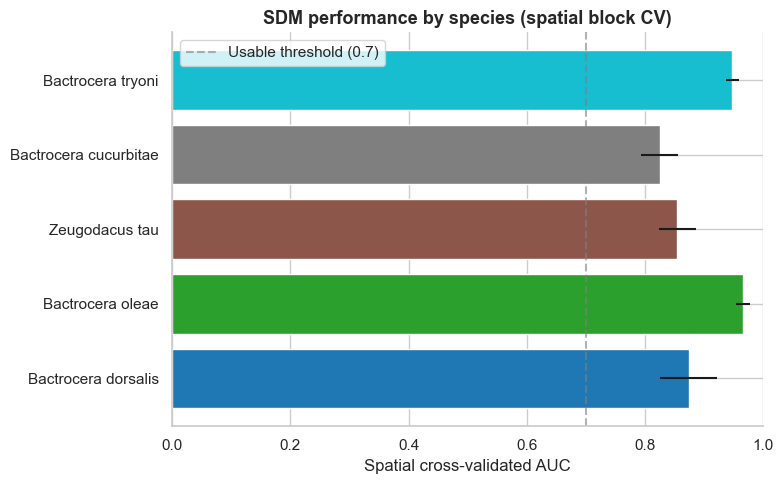

In [37]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))
ax.barh(results_df['species'], results_df['auc'], xerr=results_df['auc_std'], color=colors)
ax.axvline(0.7, color='gray', linestyle='--', alpha=0.6, label='Usable threshold (0.7)')
ax.set_xlabel('Spatial cross-validated AUC')
ax.set_title('SDM performance by species (spatial block CV)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/figures/sdm_auc_by_species.png', dpi=150)
plt.show()

# Check feature importance (sanity check on what's driving predictions)

In [38]:
importance_rows = []
for species, model in models.items():
    importances = pd.Series(model.feature_importances_, index=covariate_cols)
    top5 = importances.sort_values(ascending=False).head(5)
    for cov, val in top5.items():
        importance_rows.append({'species': species, 'covariate': cov, 'importance': val})

importance_df = pd.DataFrame(importance_rows)
importance_df.pivot(index='species', columns='covariate', values='importance').fillna(0)

covariate,bio_1,bio_10,bio_11,bio_12,bio_13,bio_15,bio_16,bio_18,bio_2,bio_3,bio_4,bio_6,bio_7,bio_8,clay
species,,,,,,,,,,,,,,,
Bactrocera cucurbitae,0.090936,0.000000,0.071886,0.000000,0.000000,0.00000,0.000000,0.000000,0.056633,0.000000,0.000000,0.096700,0.000000,0.000000,0.069862
Bactrocera dorsalis,0.000000,0.000000,0.058006,0.000000,0.000000,0.00000,0.000000,0.000000,0.140394,0.000000,0.000000,0.103716,0.095887,0.000000,0.070668
Bactrocera oleae,0.101006,0.000000,0.067077,0.000000,0.082086,0.00000,0.000000,0.145865,0.000000,0.000000,0.000000,0.000000,0.000000,0.192177,0.000000
Bactrocera tryoni,0.000000,0.076185,0.000000,0.000000,0.000000,0.07358,0.000000,0.000000,0.000000,0.134948,0.072908,0.000000,0.000000,0.000000,0.119625
Zeugodacus tau,0.000000,0.000000,0.000000,0.095039,0.064456,0.00000,0.068165,0.105726,0.081715,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Build a prediction grid and map suitability

In [39]:
def build_local_prediction_grid(presence_df, step=0.25, buffer_deg=5.0):
    """Build a prediction grid local to where a species actually occurs,
    rather than a global grid, to avoid the antimeridian bounding-box issue
    and keep prediction runtime reasonable."""
    lat_min, lat_max = presence_df['latitude'].min() - buffer_deg, presence_df['latitude'].max() + buffer_deg
    lon_min, lon_max = presence_df['longitude'].min() - buffer_deg, presence_df['longitude'].max() + buffer_deg
    lats = np.arange(max(lat_min, -90), min(lat_max, 90), step)
    lons = np.arange(max(lon_min, -180), min(lon_max, 180), step)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    return pd.DataFrame({'latitude': lat_grid.ravel(), 'longitude': lon_grid.ravel()})

In [40]:
species_to_plot = results_df.sort_values('auc', ascending=False)['species'].iloc[0]
plot_presence = species_covariates[species_covariates['scientific_name'] == species_to_plot]
print('Mapping suitability for:', species_to_plot)

grid = build_local_prediction_grid(plot_presence, step=0.25, buffer_deg=5.0)
grid = extract_covariates(grid)
grid = grid.dropna(subset=covariate_cols)
if grid['ph'].max() > 14:
    grid['ph'] = grid['ph'] / 10
print('Grid points for prediction:', len(grid))

Mapping suitability for: Bactrocera oleae
Grid points for prediction: 97795


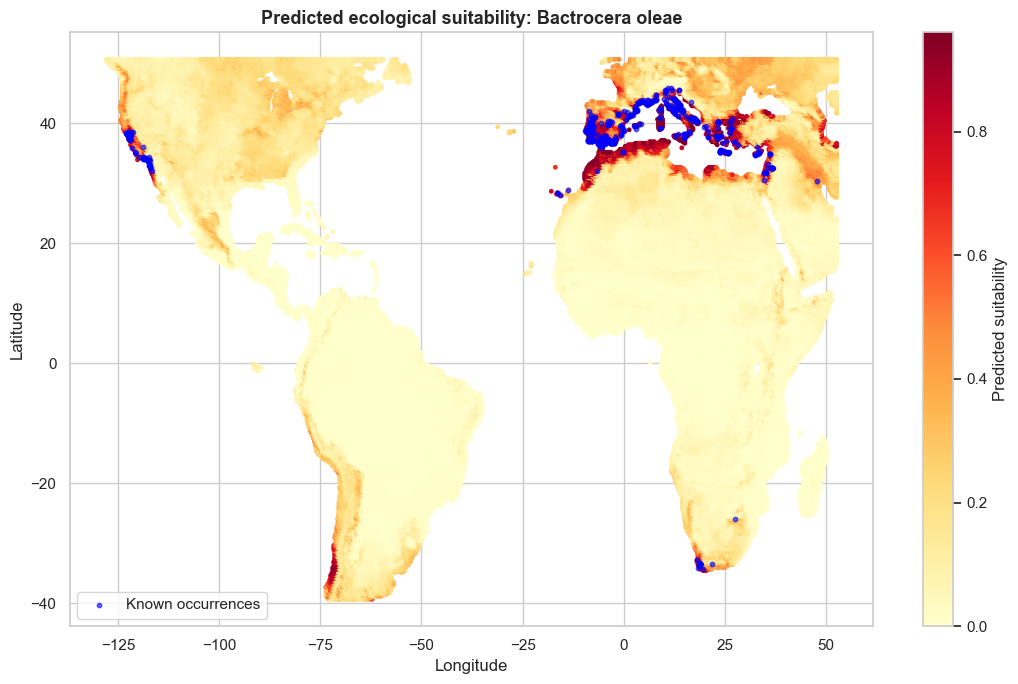

In [41]:
grid['suitability'] = models[species_to_plot].predict_proba(grid[covariate_cols])[:, 1]

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(grid['longitude'], grid['latitude'], c=grid['suitability'], cmap='YlOrRd', s=6)
ax.scatter(plot_presence['longitude'], plot_presence['latitude'], c='blue', s=10, alpha=0.6, label='Known occurrences')
plt.colorbar(sc, label='Predicted suitability')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Predicted ecological suitability: {species_to_plot}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/suitability_map_top_species.png', dpi=150)
plt.show() 

In [43]:
import joblib

for species, model in models.items():
    safe_name = species.replace(' ', '_')
    joblib.dump(model, f'../outputs/models/sdm_{safe_name}.joblib')

results_df.to_csv('../outputs/models/sdm_performance_summary.csv', index=False)
importance_df.to_csv('../outputs/models/sdm_feature_importance.csv', index=False)